In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from evaluation.portfolio import portfolio_roi, portfolio_kelly, portfolio_breakdown

abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')
ts = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season.parquet')
final = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season_final.parquet')
thr = json.load(open('C:/Users/twluc/frame/01_data/02_features/thresholds.json'))

In [2]:
final = (
    final
    .sort_values(['league', 'season', 'season_points_avg', 'season_goals_diff_avg'],
                 ascending=[True, True, False, False])
    .assign(standing=lambda df: df.groupby(['league', 'season']).cumcount() + 1)
)

In [3]:
def plot_foragst_scatter(df, group):
    groups = df[group].unique()
    colors = dict(zip(groups, plt.cm.tab20.colors))

    fig, ax = plt.subplots(figsize=(9, 7))
    for grp_val, grp in df.groupby(group):
        ax.scatter(grp['season_shots_on_target_for_avg'], grp['season_shots_on_target_agst_avg'], label=grp_val, alpha=0.6, s=20)

    for v in [thr['shots_on_target_foragst_p33'], thr['shots_on_target_foragst_p67']]:
        ax.axvline(v, color='gray', linewidth=0.6, linestyle='--')
        ax.axhline(v, color='gray', linewidth=0.6, linestyle='--')

    ax.set_xlabel('shots on target scored avg')
    ax.set_ylabel('shots on target conceded avg')

    ax.set_xlim(0, 9) 
    ax.set_ylim(0, 9)
    
    ax.legend(markerscale=2, fontsize=8)
    
    plt.tight_layout()
    plt.show()

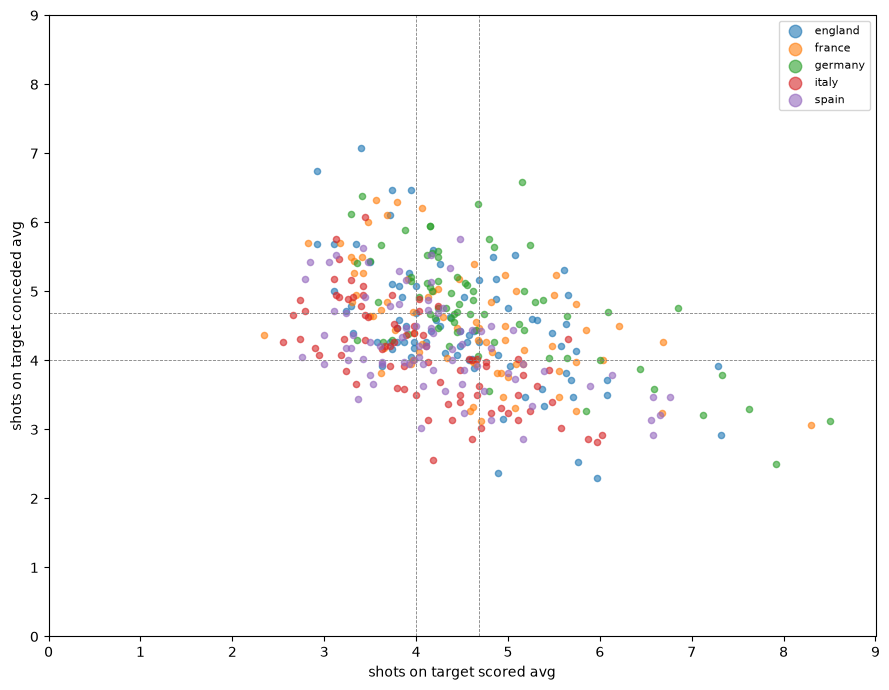

In [4]:
plot_foragst_scatter(final,'league')

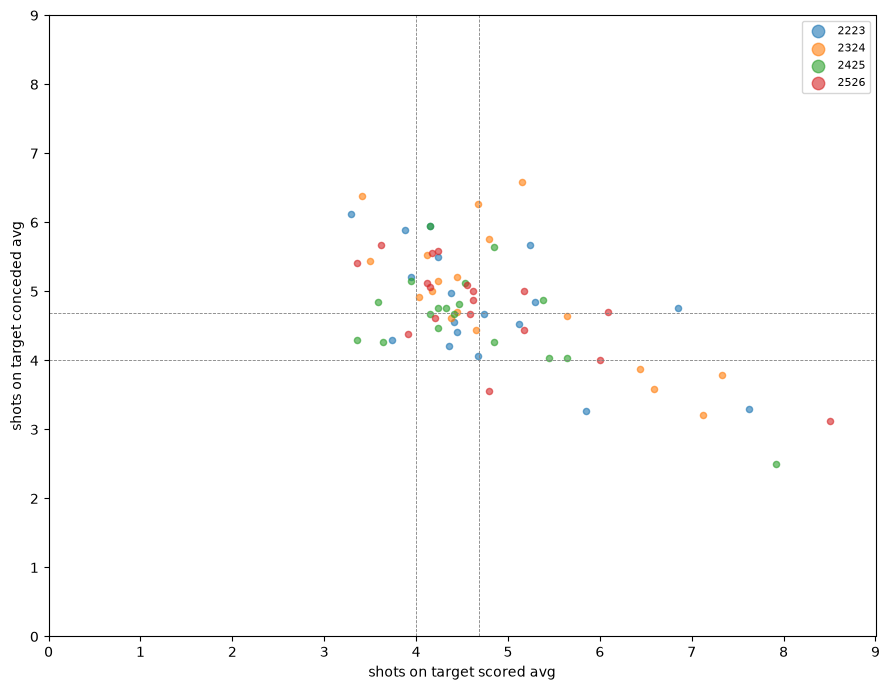

In [5]:
england = final[final['league']=='germany']
plot_foragst_scatter(england,'season')

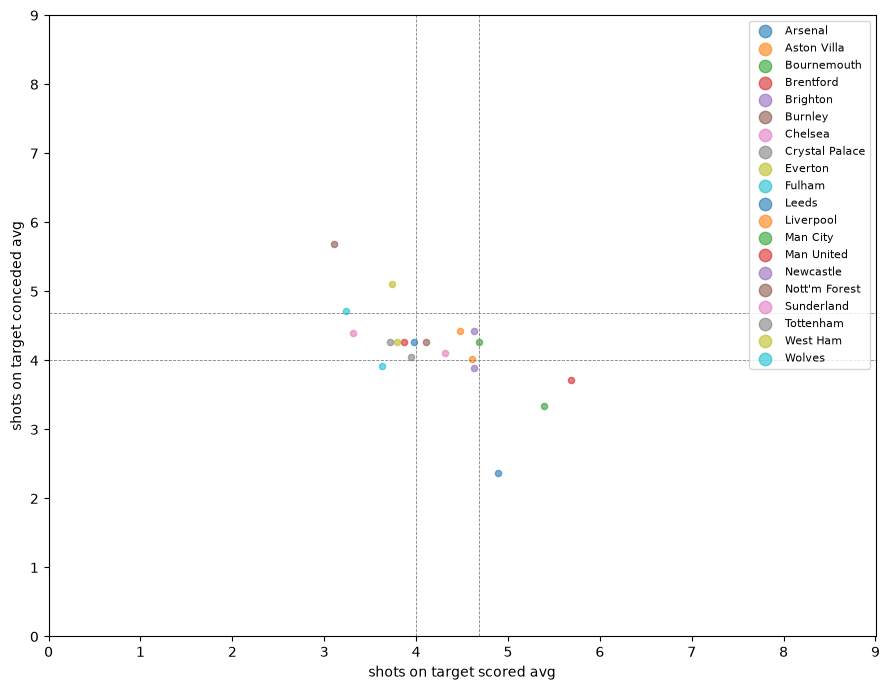

In [6]:
england2526 = final.query("league == 'england' and season == '2526'")
plot_foragst_scatter(england2526,'team')

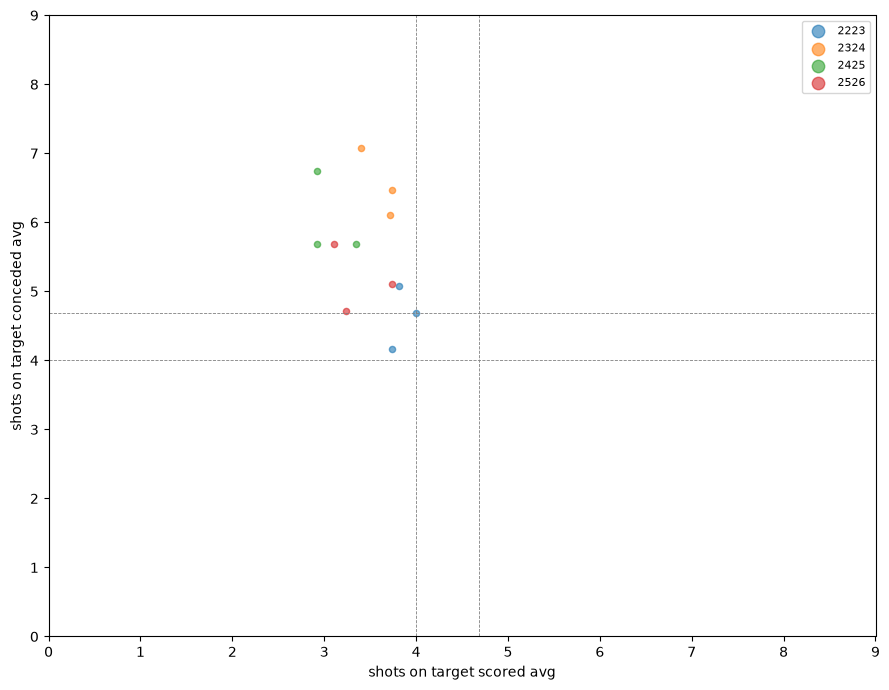

In [7]:
query = "league == 'england' and standing >= 18"
plot_foragst_scatter(final.query(query),'season')

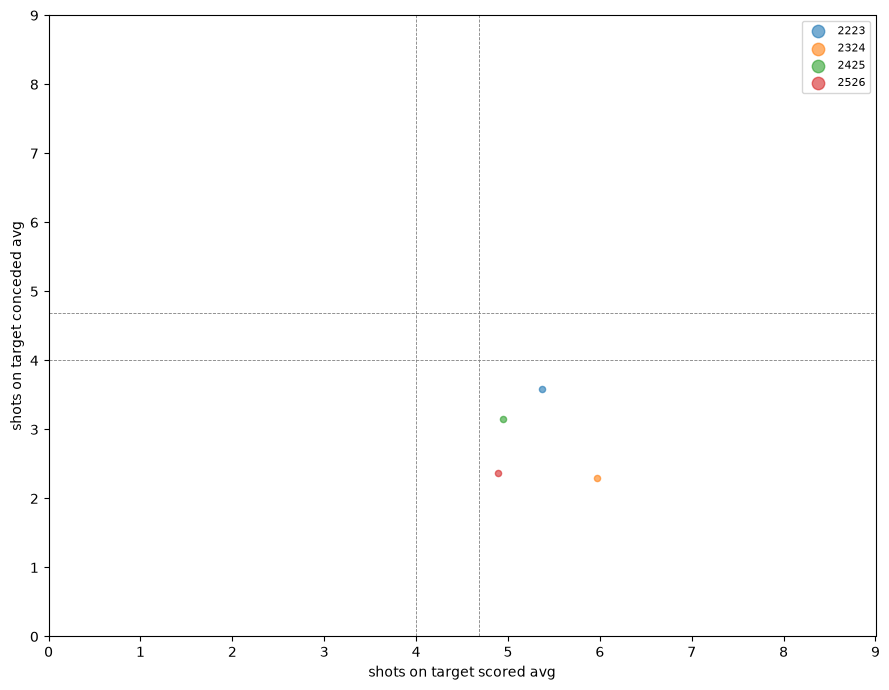

In [8]:
query = "team == 'Arsenal'"
plot_foragst_scatter(final.query(query),'season')

In [12]:
final.groupby(['league', 'season_shots_on_target_for_cat3q']).size().unstack()[['low','medium','high']]

season_shots_on_target_for_cat3q,low,medium,high
league,,,
england,31,18,31
france,26,17,31
germany,13,33,26
italy,41,19,20
spain,34,27,19


In [13]:
final.groupby(['league', 'season_shots_on_target_agst_cat3q']).size().unstack()[['low','medium','high']]

season_shots_on_target_agst_cat3q,low,medium,high
league,,,
england,18,33,29
france,22,23,29
germany,10,22,40
italy,37,25,18
spain,35,24,21


In [17]:
sub = abt[abt['hmt_game_number'] > 8]
cols = ['hmt_season_shots_on_target_for_cat2m', 'hmt_season_shots_on_target_agst_cat2m',
        'awt_season_shots_on_target_for_cat2m', 'awt_season_shots_on_target_agst_cat2m']

groups = {k: g for k, g in sub.groupby(cols)}
results = {k: portfolio_roi(g['mrkt_draw_impl'], g['t_draw_flg']) for k, g in groups.items()}
for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
    pval = binomtest(r['wins'], r['n_bets'], groups[k]['mrkt_draw_impl'].mean()).pvalue
    print(k, f"roi={r['roi']:.3f}  n={r['n_bets']}  p={pval:.3f}")


('high', 'high', 'low', 'high') roi=0.236  n=240  p=0.048
('low', 'low', 'low', 'high') roi=0.096  n=419  p=0.229
('low', 'high', 'low', 'high') roi=0.063  n=606  p=0.324
('high', 'high', 'high', 'high') roi=0.234  n=172  p=0.080
('high', 'high', 'low', 'low') roi=0.179  n=95  p=0.298
('low', 'high', 'high', 'high') roi=-0.010  n=262  p=1.000
('low', 'low', 'low', 'low') roi=-0.028  n=338  p=0.767
('high', 'low', 'low', 'low') roi=-0.034  n=412  p=0.728
('low', 'low', 'high', 'high') roi=-0.145  n=88  p=0.476
('low', 'high', 'low', 'low') roi=-0.038  n=394  p=0.660
('high', 'high', 'high', 'low') roi=-0.153  n=215  p=0.209
('high', 'low', 'high', 'high') roi=-0.192  n=212  p=0.160
('low', 'high', 'high', 'low') roi=-0.076  n=590  p=0.297
('low', 'low', 'high', 'low') roi=-0.110  n=404  p=0.183
('high', 'low', 'low', 'high') roi=-0.171  n=549  p=0.047
('high', 'low', 'high', 'low') roi=-0.228  n=541  p=0.001


In [18]:
from sklearn.cluster import KMeans

In [31]:
def cluster_roi(n_clusters):
    km = KMeans(n_clusters=n_clusters, random_state=0)
    final[f'kmeans_cluster{n_clusters}'] = km.fit_predict(final[['season_shots_on_target_for_avg', 'season_shots_on_target_agst_avg']]).astype(str)
    plot_foragst_scatter(final, f'kmeans_cluster{n_clusters}')

    sub = abt[abt['hmt_game_number'] > 8].copy() 
    
    sub['hmt_km'] = km.predict(sub[['hmt_season_shots_on_target_for_avg', 'hmt_season_shots_on_target_agst_avg']].rename(columns=lambda c: c.replace('hmt_', ''))).astype(str)
    sub['awt_km'] = km.predict(sub[['awt_season_shots_on_target_for_avg', 'awt_season_shots_on_target_agst_avg']].rename(columns=lambda c: c.replace('awt_', ''))).astype(str)

    groups = {k: g for k, g in sub.groupby(['hmt_km', 'awt_km'])}
    results = {k: portfolio_roi(g['mrkt_draw_impl'], g['t_draw_flg']) for k, g in groups.items()}
    for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):        
        g = groups[k]
        pval = binomtest(r['wins'], r['n_bets'], g['mrkt_draw_impl'].mean()).pvalue
        print(k, r, f"p={pval:.3f}")


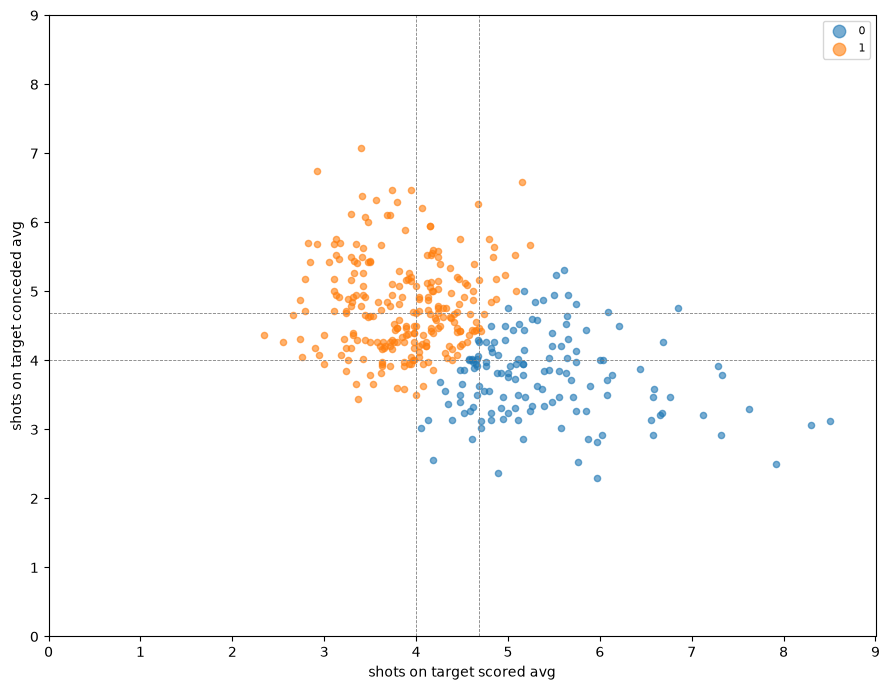

('1', '1') {'n_bets': 2178, 'capital': 622.036, 'wins': 631, 'profit': 8.964, 'roi': 0.0144} p=0.669
('0', '1') {'n_bets': 1265, 'capital': 269.318, 'wins': 256, 'profit': -13.318, 'roi': -0.0495} p=0.372
('1', '0') {'n_bets': 1311, 'capital': 343.641, 'wins': 326, 'profit': -17.641, 'roi': -0.0513} p=0.286
('0', '0') {'n_bets': 783, 'capital': 204.586, 'wins': 170, 'profit': -34.586, 'roi': -0.1691} p=0.005


In [32]:
cluster_roi(2)

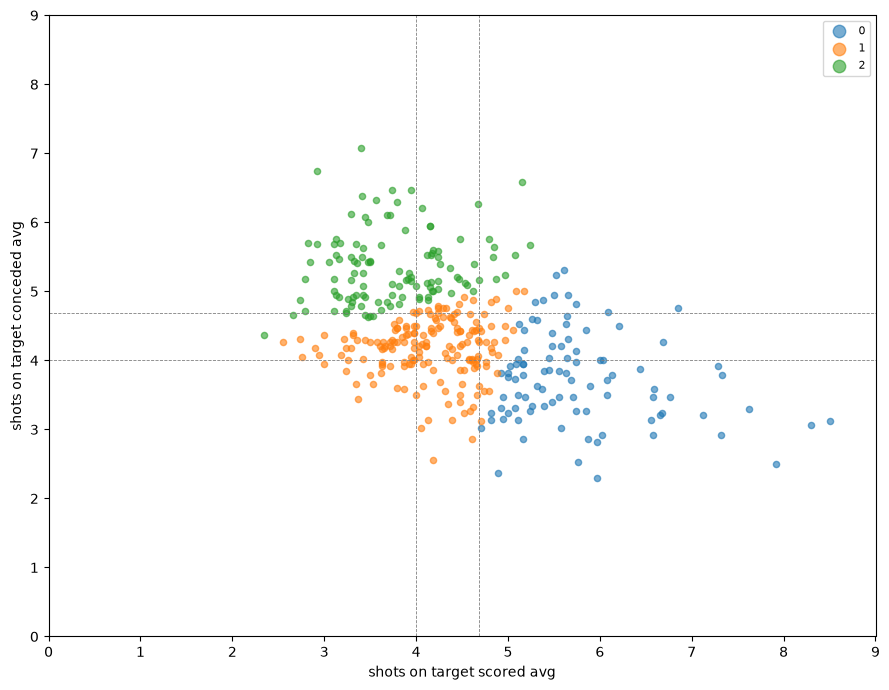

('1', '2') {'n_bets': 728, 'capital': 189.065, 'wins': 207, 'profit': 17.935, 'roi': 0.0949} p=0.139
('2', '2') {'n_bets': 568, 'capital': 158.464, 'wins': 165, 'profit': 6.536, 'roi': 0.0412} p=0.543
('2', '1') {'n_bets': 751, 'capital': 218.343, 'wins': 217, 'profit': -1.343, 'roi': -0.0062} p=0.936
('1', '0') {'n_bets': 583, 'capital': 155.906, 'wins': 151, 'profit': -4.906, 'roi': -0.0315} p=0.674
('0', '2') {'n_bets': 443, 'capital': 80.878, 'wins': 73, 'profit': -7.878, 'roi': -0.0974} p=0.356
('2', '0') {'n_bets': 477, 'capital': 113.352, 'wins': 104, 'profit': -9.352, 'roi': -0.0825} p=0.333
('0', '0') {'n_bets': 316, 'capital': 80.506, 'wins': 63, 'profit': -17.506, 'roi': -0.2174} p=0.024
('0', '1') {'n_bets': 603, 'capital': 135.108, 'wins': 116, 'profit': -19.108, 'roi': -0.1414} p=0.063
('1', '1') {'n_bets': 1068, 'capital': 307.959, 'wins': 287, 'profit': -20.959, 'roi': -0.0681} p=0.166


In [37]:
cluster_roi(3)

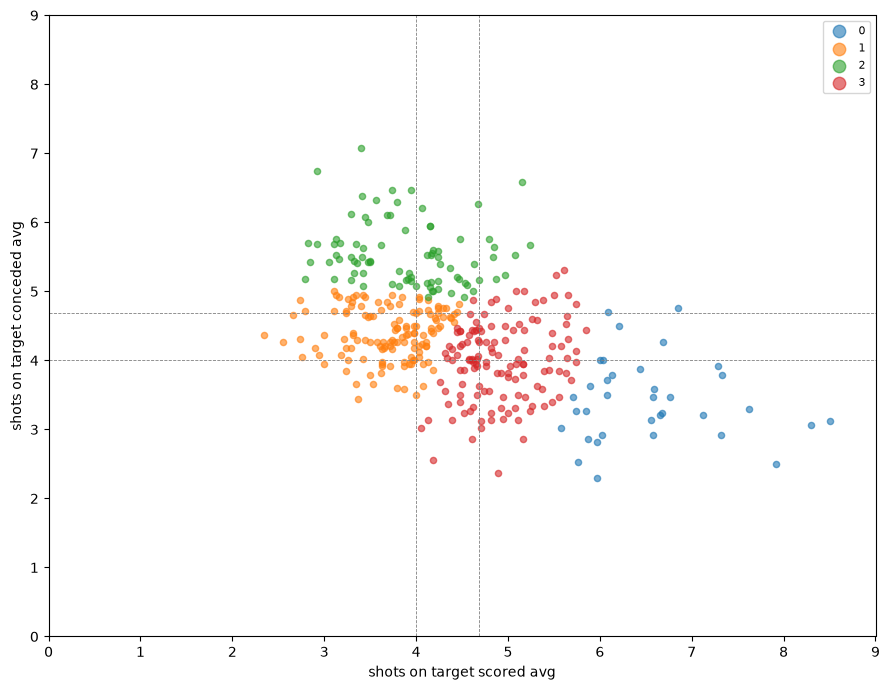

('2', '1') {'n_bets': 376, 'capital': 110.129, 'wins': 122, 'profit': 11.871, 'roi': 0.1078} p=0.192
('1', '1') {'n_bets': 660, 'capital': 199.79, 'wins': 206, 'profit': 6.21, 'roi': 0.0311} p=0.611
('2', '3') {'n_bets': 462, 'capital': 122.922, 'wins': 126, 'profit': 3.078, 'roi': 0.025} p=0.752
('1', '2') {'n_bets': 410, 'capital': 113.294, 'wins': 115, 'profit': 1.706, 'roi': 0.0151} p=0.868
('3', '2') {'n_bets': 405, 'capital': 87.919, 'wins': 89, 'profit': 1.081, 'roi': 0.0123} p=0.904
('0', '3') {'n_bets': 165, 'capital': 35.381, 'wins': 36, 'profit': 0.619, 'roi': 0.0175} p=0.924
('0', '2') {'n_bets': 149, 'capital': 21.938, 'wins': 21, 'profit': -0.938, 'roi': -0.0428} p=0.908
('1', '0') {'n_bets': 160, 'capital': 37.939, 'wins': 37, 'profit': -0.939, 'roi': -0.0248} p=0.926
('3', '1') {'n_bets': 587, 'capital': 145.067, 'wins': 144, 'profit': -1.067, 'roi': -0.0074} p=0.962
('0', '0') {'n_bets': 55, 'capital': 13.175, 'wins': 10, 'profit': -3.175, 'roi': -0.241} p=0.429
('2', 

In [34]:
cluster_roi(4)

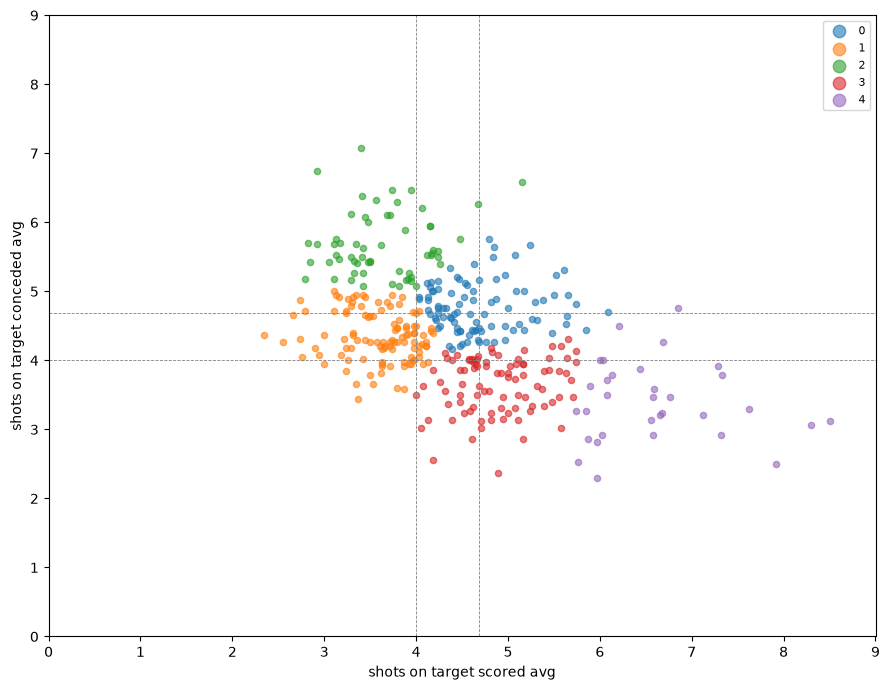

('0', '0') {'n_bets': 316, 'capital': 82.953, 'wins': 90, 'profit': 7.047, 'roi': 0.085} p=0.371
('1', '1') {'n_bets': 511, 'capital': 156.223, 'wins': 163, 'profit': 6.777, 'roi': 0.0434} p=0.533
('0', '1') {'n_bets': 223, 'capital': 61.214, 'wins': 66, 'profit': 4.786, 'roi': 0.0782} p=0.499
('2', '1') {'n_bets': 259, 'capital': 77.607, 'wins': 82, 'profit': 4.393, 'roi': 0.0566} p=0.542
('0', '2') {'n_bets': 233, 'capital': 54.739, 'wins': 59, 'profit': 4.261, 'roi': 0.0778} p=0.536
('3', '2') {'n_bets': 211, 'capital': 43.508, 'wins': 47, 'profit': 3.492, 'roi': 0.0803} p=0.552
('4', '3') {'n_bets': 104, 'capital': 23.347, 'wins': 26, 'profit': 2.653, 'roi': 0.1136} p=0.557
('1', '2') {'n_bets': 285, 'capital': 79.34, 'wins': 81, 'profit': 1.66, 'roi': 0.0209} p=0.843
('4', '2') {'n_bets': 99, 'capital': 13.859, 'wins': 15, 'profit': 1.141, 'roi': 0.0823} p=0.771
('2', '0') {'n_bets': 243, 'capital': 66.117, 'wins': 67, 'profit': 0.883, 'roi': 0.0134} p=0.886
('2', '3') {'n_bets': 

In [36]:
cluster_roi(5)